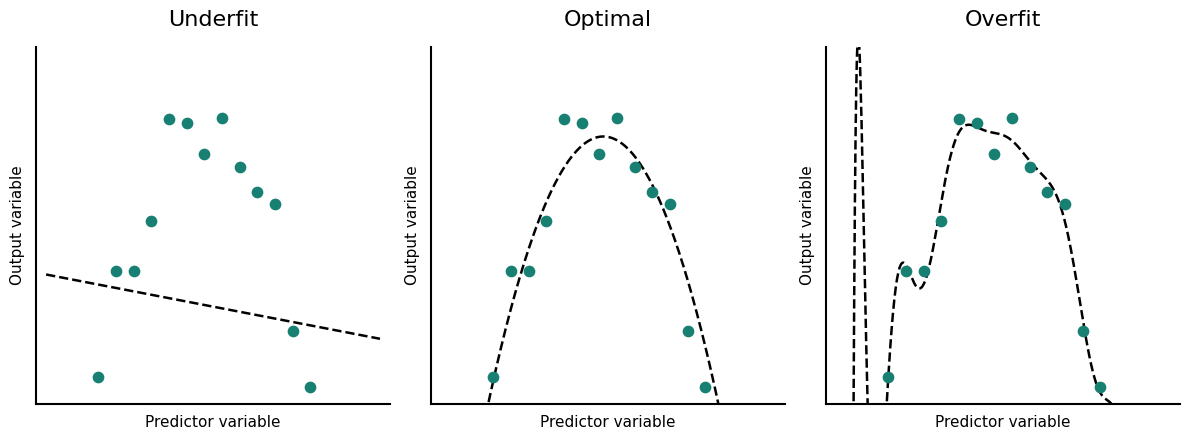

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Imposta il seed per la riproducibilità dei punti casuali
np.random.seed(42)

# 1. Generazione dei dati (andamento parabolico con rumore)
n_points = 18
x = np.linspace(1, 10, n_points)
# Funzione quadratica di base + rumore gaussiano
y = -0.5 * (x - 5.5)**2 + 10 + np.random.normal(0, 0.8, size=n_points)

# Genera punti densi per disegnare curve fluide
x_fine = np.linspace(0.5, 10.5, 500)

# 2. Calcolo dei modelli polinomiali
# Underfit: retta (grado 1)
coef_under = np.polyfit(x, y, 1)
y_under = np.polyval(coef_under, x_fine)

# Optimal: parabola (grado 2)
coef_opt = np.polyfit(x, y, 2)
y_opt = np.polyval(coef_opt, x_fine)

# Overfit: polinomio ad alto grado (grado 14)
coef_over = np.polyfit(x, y, 14)
y_over = np.polyval(coef_over, x_fine)

# 3. Creazione del grafico
fig, axs = plt.subplots(1, 3, figsize=(12, 4.5), sharey=True)

# Definiamo i colori e gli stili per matchare l'immagine originale
teal_color = "#178073"  # Colore dei punti (verde acqua/teal)
line_style = 'k--'      # Linea nera tratteggiata

# Titoli e dati per i tre subplot
plots_data = [
    ("Underfit", y_under),
    ("Optimal", y_opt),
    ("Overfit", y_over)
]

for i, (title, y_curve) in enumerate(plots_data):
    ax = axs[i]
    
    # Disegna i punti reali
    ax.scatter(x, y, color=teal_color, s=55, zorder=3)
    
    # Disegna la linea del modello
    ax.plot(x_fine, y_curve, line_style, linewidth=1.8, zorder=2)
    
    # Titolo del subplot
    ax.set_title(title, fontsize=16, pad=15)
    
    # Label degli assi
    ax.set_xlabel("Predictor variable", fontsize=11, labelpad=8)
    ax.set_ylabel("Output variable", fontsize=11, labelpad=8)
    
    # Rimuove i numeri (ticks) sugli assi
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Rendi visibili solo l'asse sinistro (Y) e inferiore (X) per creare l'effetto a "L"
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # Limiti degli assi per evitare che l'overfit "schizzi" fuori scala
    ax.set_xlim(0.2, 10.8)
    ax.set_ylim(4, 12)

# Ottimizza lo spazio tra i grafici e mostra il risultato
plt.tight_layout()

# Salva l'immagine (opzionale)
# plt.savefig('underfitting_overfitting.png', dpi=300, bbox_inches='tight')

plt.show()

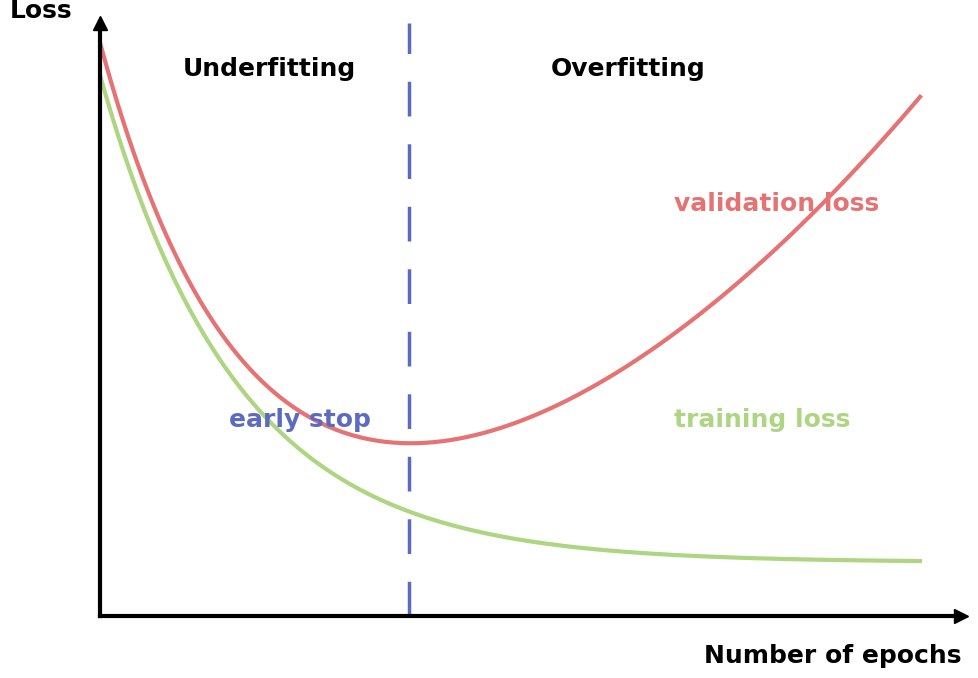

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definiamo i dati sintetici per le curve di loss
epochs = np.linspace(0, 100, 200)

# Curva di training loss: scende rapidamente e poi si appiattisce
train_loss = 0.9 * np.exp(-0.06 * epochs) + 0.1

# Curva di validation loss: scende inizialmente (come train) e poi risale
# Aggiungiamo un termine esponenziale per simulare l'overfitting
val_loss = 0.9 * np.exp(-0.06 * epochs) + 0.15 + 0.0001 * (epochs - 10)**2

# Trova il punto minimo della validation loss per l'early stopping
min_val_loss_idx = np.argmin(val_loss)
early_stop_epoch = epochs[min_val_loss_idx]

# 2. Configurazione del grafico
plt.figure(figsize=(10, 7))  # Dimensioni del plot
plt.rcParams['font.size'] = 14  # Dimensione dei font

# Colori ripresi dall'immagine originale
color_red = '#e57373'  # Rosso chiaro
color_green = '#aed581' # Verde chiaro
color_blue = '#5c6bc0'  # Blu scuro (tratteggiato)

# --- Plot delle curve ---
plt.plot(epochs, val_loss, label='validation loss', color=color_red, linewidth=3)
plt.plot(epochs, train_loss, label='training loss', color=color_green, linewidth=3)

# --- Plot della linea verticale di early stopping ---
plt.axvline(x=early_stop_epoch, color=color_blue, linestyle='--', linewidth=2.5, dashes=(10, 8))

# 3. Testi e annotazioni all'interno del grafico
# Etichette principali in alto
plt.text(10, 1.0, 'Underfitting', fontsize=18, fontweight='bold')
plt.text(55, 1.0, 'Overfitting', fontsize=18, fontweight='bold')

# Etichetta "early stop" vicino alla linea tratteggiata
plt.text(early_stop_epoch - 22, 0.35, 'early stop', fontsize=18, color=color_blue, fontweight='bold')

# Etichette delle curve a destra
plt.text(70, 0.75, 'validation loss', fontsize=18, color=color_red, fontweight='bold')
plt.text(70, 0.35, 'training loss', fontsize=18, color=color_green, fontweight='bold')

# 4. Configurazione degli assi e dell'aspetto generale
# Etichette degli assi (come nell'immagine, a destra per X, in alto per Y)
plt.ylabel('Loss', loc='top', rotation=0, labelpad=20, fontsize=18, fontweight='bold')
plt.xlabel('Number of epochs', loc='right', labelpad=20, fontsize=18, fontweight='bold')

# Limiti degli assi per mostrare bene le curve
plt.xlim(0, 105)
plt.ylim(0, 1.1)

# Rimuovi i numeri (ticks) sugli assi
plt.xticks([])
plt.yticks([])

# Rendi più spessi gli assi sinistro e inferiore
ax = plt.gca()
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)

# Nascondi i bordi superiore e destro
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Aggiungi le frecce alle estremità degli assi
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, ms=10) # Freccia asse X
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, ms=10) # Freccia asse Y

plt.tight_layout()

# Salva l'immagine (opzionale)
# plt.savefig('loss_curves.png', dpi=300)

plt.show()